In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import stats
import config
import analysis_lib as alib
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)  # Suppress warnings for NaNs in correlation

# --- CONFIGURATION ---
START_YEAR = 1981
END_YEAR = 2014
OMEGA_LEVEL = 500  # hPa
SIGNIFICANCE_LEVEL = 0.05  # 95% Confidence

# Smoothing Settings
APPLY_SMOOTHING = True
SMOOTH_WINDOW = 5  

# =========================================================================
#  MONKEY PATCH: FIX MISSING UNITS
# =========================================================================
_original_convert = alib.convert_precip_units

def safe_convert_precip_units(da):
    """
    Wrapper that forces units if they are missing (likely stripped by regridder).
    """
    if 'units' not in da.attrs or not da.attrs['units']:
        print("   [Patch] Units attribute missing. Forcing 'mm/month' to prevent crash.")
        da.attrs['units'] = 'mm/month'
    return _original_convert(da)

alib.convert_precip_units = safe_convert_precip_units

In [2]:
print("1. Loading Data...")

# A. Precip
_, _, pr_ds = alib.load_processed_obs(load_full_range=False)
pr_ds = pr_ds.sel(time=slice(str(START_YEAR), str(END_YEAR)))

# B. Omega
era5_path = config.DATA_DIR / 'ERA5' / 'era500.nc'
try:
    era5_ds = xr.open_dataset(era5_path)
    if 'latitude' in era5_ds.coords: era5_ds = era5_ds.rename({'latitude': 'lat', 'longitude': 'lon'})
    if 'valid_time' in era5_ds.dims: era5_ds = era5_ds.rename({'valid_time': 'time'})
    
    plevel_name = 'pressure_level' if 'pressure_level' in era5_ds.dims else 'level'
    w_raw = era5_ds['w'].sel({plevel_name: OMEGA_LEVEL}, method='nearest')
    w_raw = w_raw.sel(time=slice(str(START_YEAR), str(END_YEAR)))
    
    if w_raw.lon.max() > 180:
        w_raw = w_raw.assign_coords(lon=(((w_raw.lon + 180) % 360) - 180)).sortby('lon')
        
except Exception as e:
    print(f"   [!] Error loading ERA5: {e}")

# --- Select variables from the desired pressure level ---
print(f"Selecting data for {OMEGA_LEVEL}hPa pressure level...")
plevel_name = 'pressure_level' if 'pressure_level' in era5_ds.dims else 'level'
omega_level = era5_ds['w'].sel({plevel_name: OMEGA_LEVEL}, method='nearest')
u_level = era5_ds['u'].sel({plevel_name: OMEGA_LEVEL}, method='nearest')
v_level = era5_ds['v'].sel({plevel_name: OMEGA_LEVEL}, method='nearest') 


print("2. Regridding ERA5...")
regridder = alib.get_regridder(w_raw, method='bilinear')
w_regridded = regridder(w_raw)



1. Loading Data...
--- (Lib) Loading Observations (Full Range=False) ---
--- (Helper) Loading HadISST to create universal land mask ---


/nas/home/leo/Documents/scripts/regression_script/analysis_lib.py:188: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  with xr.open_mfdataset(sst_path, combine='by_coords', decode_times=time_coder) as ds_sst_raw:


    -> Standardizing coordinates...
       - Renamed: {'latitude': 'lat', 'longitude': 'lon'}
       - Sorted by 1D 'lat' dim
       - Sorted by 1D 'lon' dim
  -> Creating land-sea mask from source grid...
       - Clipped 'lat' to [-90, 90] for regridder.
    -> Creating bilinear regridder to 1x1 grid...
✅ Universal land mask (1x1) is ready.


/nas/home/leo/Documents/scripts/regression_script/analysis_lib.py:230: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  with xr.open_mfdataset(config.SST_PATH, combine='by_coords', use_cftime=True) as ds:


    -> Standardizing coordinates...
       - Renamed: {'latitude': 'lat', 'longitude': 'lon'}
       - Sorted by 1D 'lat' dim
       - Sorted by 1D 'lon' dim
       - Clipped 'lat' to [-90, 90] for regridder.
    -> Reusing bilinear weights from: weights_obs_hadisst_bilinear.nc
    -> Standardizing coordinates...
       - Sorted by 1D 'lat' dim
       - Sorted by 1D 'lon' dim
       - Clipped 'lat' to [-90, 90] for regridder.
    -> Reusing conservative weights from: weights_obs_gpcc_conservative.nc


/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/xesmf/backend.py:56: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


   [Patch] Units attribute missing. Forcing 'mm/month' to prevent crash.
       [Unit Check] Metadata says: 'mm/month'
       -> Detected mm. Keeping as is.
Selecting data for 500hPa pressure level...
2. Regridding ERA5...
       - Clipped 'lat' to [-90, 90] for regridder.
    -> Creating bilinear regridder to 1x1 grid...


/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')



--- Generating Grouped 2x2 Plot ---
 -> Processing MAM...


 -> Processing MARCH...
 -> Processing APRIL...
 -> Processing MAY...


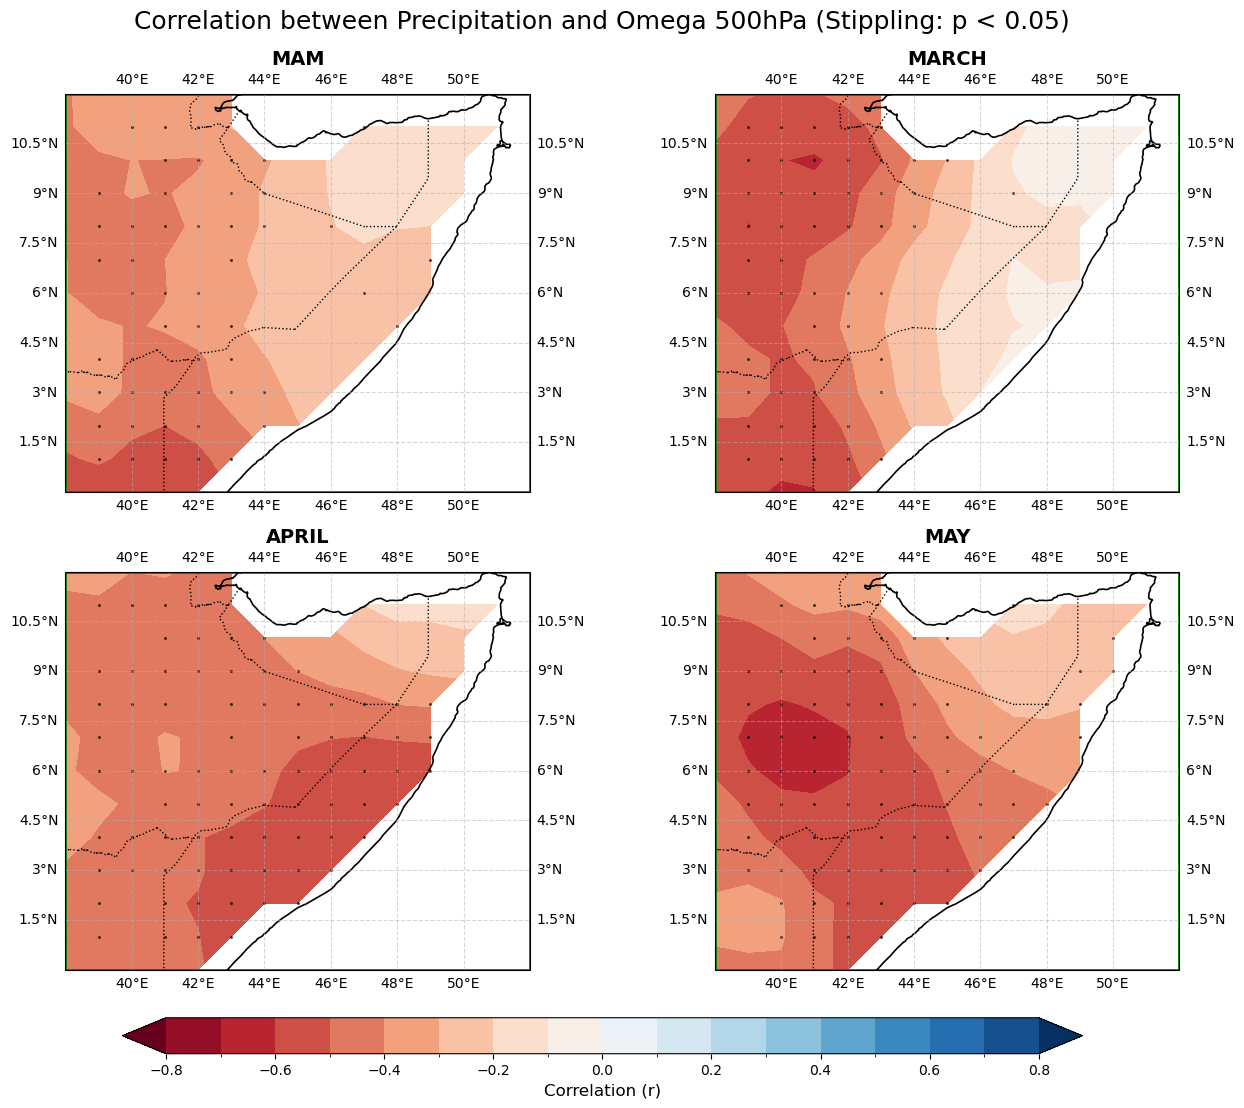

 ✅ Saved grouped plot to /nas/home/leo/Documents/scripts/regression_script/unified_analysis_output/figures/map_correlation_grouped.png


In [3]:
# %% MULTI-PANEL GROUPED PLOT: CORRELATION & SIGNIFICANCE

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from scipy import stats
from scipy.stats import spearmanr

print("\n--- Generating Grouped 2x2 Plot ---")

# 1. Setup the 2x2 Figure Grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten() # Flatten the 2x2 array into a 1D list so we can loop over it easily
extent = [38, 52, 0, 12] 
cmap = 'RdBu'
levels = np.linspace(-0.8, 0.8, 17)

# We will store one of the contour plots to use for the shared colorbar later
cf_plot = None 

# 2. Loop through Periods and Axes simultaneously
for i, (period_name, months) in enumerate(config.ANALYSIS_PERIODS.items()):
    ax = axes[i]
    print(f" -> Processing {period_name.upper()}...")

    # --- DATA PROCESSING (Detrending & Neff) ---
    pr_yearly = pr_ds.sel(time=pr_ds['time.month'].isin(months)).groupby('time.year').mean('time')
    w_yearly = w_regridded.sel(time=w_regridded['time.month'].isin(months)).groupby('time.year').mean('time')

    #calculate anomalies and detrend
    common_years = np.intersect1d(pr_yearly.year, w_yearly.year)
    pr_core = pr_yearly.sel(year=common_years)
    w_core = w_yearly.sel(year=common_years)
    N = len(common_years)

    pr_anom = pr_core - pr_core.mean('year')
    w_anom = w_core - w_core.mean('year')

    pr_trend = pr_anom.polyfit(dim='year', deg=1)
    w_trend = w_anom.polyfit(dim='year', deg=1)

    pr_fit = xr.polyval(pr_anom['year'], pr_trend.polyfit_coefficients)
    w_fit = xr.polyval(w_anom['year'], w_trend.polyfit_coefficients)

    pr_detrended = pr_anom - pr_fit
    w_detrended = w_anom - w_fit
    
    pr_detrended = pr_detrended.chunk({'year': -1})
    w_detrended = w_detrended.chunk({'year': -1})

    #calcualte spearman ranks
    pr_ranked = pr_detrended.rank(dim='year')
    w_ranked = w_detrended.rank(dim='year')
    
    corr = xr.corr(pr_ranked, w_ranked, dim='year').compute()
    corr_np = corr.values

    r1_pr = np.nan_to_num(xr.corr(pr_detrended, pr_detrended.shift(year=1), dim='year').values, nan=0.0)
    r1_w = np.nan_to_num(xr.corr(w_detrended, w_detrended.shift(year=1), dim='year').values, nan=0.0)

    N_eff = np.clip(N * ((1 - r1_pr * r1_w) / (1 + r1_pr * r1_w)), 3, N)
    df = N_eff - 2 

    r_sq = np.clip(corr_np**2, 0, 0.999999) 
    t_stat = corr_np * np.sqrt(df / (1 - r_sq))
    p_vals_np = stats.t.sf(np.abs(t_stat), df) * 2

    pval = xr.DataArray(p_vals_np, coords=corr.coords, dims=corr.dims)

    if APPLY_SMOOTHING:
        corr_smooth = corr.rolling(lat=SMOOTH_WINDOW, lon=SMOOTH_WINDOW, center=True, min_periods=1).mean()
        corr_smooth = corr_smooth.where(corr.notnull())
    else:
        corr_smooth = corr

    # --- PLOTTING ON SPECIFIC AXIS ---
    # Note: We turn off the individual colorbars (add_colorbar=False)
    cf = corr_smooth.plot.contourf(
        ax=ax, transform=ccrs.PlateCarree(), 
        cmap=cmap, levels=levels, extend='both', add_colorbar=False
    )
    if cf_plot is None:
        cf_plot = cf # Save the first plot for the shared colorbar

    # Stippling
    sig_mask = (pval < SIGNIFICANCE_LEVEL) & corr.notnull()
    sig_data = sig_mask.where(sig_mask, drop=True)

    if sig_data.count() > 0:
        stacked = sig_mask.stack(z=('lat', 'lon'))
        significant_points = stacked[stacked] 
        ax.scatter(significant_points.lon.values, significant_points.lat.values, 
                   s=1.5, c='black', marker='o', transform=ccrs.PlateCarree(), alpha=0.6)

    # Map Formatting
    ax.add_feature(cfeature.COASTLINE, linewidth=1.2)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    # Study Box
    b = config.BOUNDS['study']
    rect = plt.Rectangle((b['lon_min'], b['lat_min']), b['lon_max']-b['lon_min'], b['lat_max']-b['lat_min'],
                         facecolor='none', edgecolor='green', linewidth=2, transform=ccrs.PlateCarree())
    ax.add_patch(rect)

    # Set individual subplot titles
    ax.set_title(f"{period_name.upper()}", fontsize=14, fontweight='bold')

# 3. Add a Shared Colorbar at the Bottom
# Adjust layout to make room for the colorbar so it doesn't overlap the maps
fig.subplots_adjust(bottom=0.15, hspace=0.2, wspace=0.1)
cbar_ax = fig.add_axes([0.2, 0.08, 0.6, 0.03]) # [left, bottom, width, height]
cbar = fig.colorbar(cf_plot, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Correlation (r)', fontsize=12)

# Overall Title
fig.suptitle(f'Correlation between Precipitation and Omega 500hPa (Stippling: p < {SIGNIFICANCE_LEVEL})', fontsize=18, y=0.95)

# Save and Show
output_file = config.FIGURE_DIR / 'map_correlation_grouped.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
plt.show()
print(f" ✅ Saved grouped plot to {output_file}")


--- Generating Time Series Trend Plot for MAY ---
 -> Calculating spatial regional averages...
 -> Calculating linear regressions...
 -> Generating dual-axis plot...


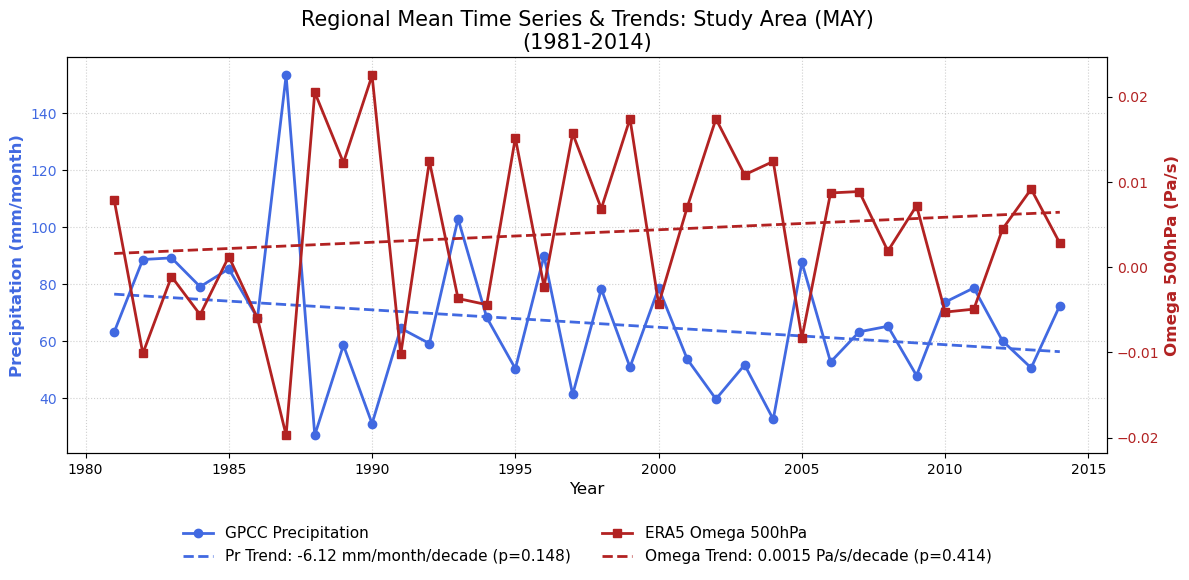

 ✅ Saved time series plot to /nas/home/leo/Documents/scripts/regression_script/unified_analysis_output/figures/timeseries_trend_precip_omega_may.png


In [4]:
# %% REGIONAL TIME SERIES AND TREND PLOT
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

print(f"\n--- Generating Time Series Trend Plot for {period_name.upper()} ---")

# 1. Subset to the Study Area Box
b = config.BOUNDS['study']

# Note: Check your dataset's latitude orientation (ascending vs descending) 
# and slice accordingly if xarray throws an empty array warning.
pr_study = pr_core.sel(lat=slice(b['lat_min'], b['lat_max']), lon=slice(b['lon_min'], b['lon_max']))
w_study = w_core.sel(lat=slice(b['lat_min'], b['lat_max']), lon=slice(b['lon_min'], b['lon_max']))

# 2. Calculate the Spatial Mean to create 1D time series
print(" -> Calculating spatial regional averages...")
pr_ts = pr_study.mean(dim=['lat', 'lon'])
w_ts = w_study.mean(dim=['lat', 'lon'])

years = pr_ts.year.values

# 3. Calculate Linear Trends for the 1D Time Series
print(" -> Calculating linear regressions...")
# linregress gives us the slope, intercept, and the p-value of the trend
pr_slope, pr_int, pr_r, pr_p, pr_err = stats.linregress(years, pr_ts.values)
w_slope, w_int, w_r, w_p, w_err = stats.linregress(years, w_ts.values)

# Reconstruct the trend lines for plotting
pr_trendline = pr_slope * years + pr_int
w_trendline = w_slope * years + w_int

# Convert slopes to decadal trends for the labels
pr_decadal = pr_slope * 10
w_decadal = w_slope * 10

# 4. PLOTTING
print(" -> Generating dual-axis plot...")
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot A: Precipitation on the primary (left) y-axis
color1 = 'royalblue'
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Precipitation (mm/month)', color=color1, fontsize=12, fontweight='bold')
line1, = ax1.plot(years, pr_ts.values, color=color1, marker='o', linewidth=2, label='GPCC Precipitation')
trend1, = ax1.plot(years, pr_trendline, color=color1, linestyle='--', linewidth=2,
                   label=f'Pr Trend: {pr_decadal:.2f} mm/month/decade (p={pr_p:.3f})')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, linestyle=':', alpha=0.6)

# Plot B: Omega on the secondary (right) y-axis
ax2 = ax1.twinx()
color2 = 'firebrick'
ax2.set_ylabel('Omega 500hPa (Pa/s)', color=color2, fontsize=12, fontweight='bold')
line2, = ax2.plot(years, w_ts.values, color=color2, marker='s', linewidth=2, label='ERA5 Omega 500hPa')
trend2, = ax2.plot(years, w_trendline, color=color2, linestyle='--', linewidth=2,
                   label=f'Omega Trend: {w_decadal:.4f} Pa/s/decade (p={w_p:.3f})')
ax2.tick_params(axis='y', labelcolor=color2)

# Combine legends from both axes and place them neatly below the chart
lines = [line1, trend1, line2, trend2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False, fontsize=11)

plt.title(f'Regional Mean Time Series & Trends: Study Area ({period_name.upper()})\n({START_YEAR}-{END_YEAR})', fontsize=15)
plt.tight_layout()

# Save and Show
output_ts_file = config.FIGURE_DIR / f'timeseries_trend_precip_omega_{period_name.lower()}.png'
plt.savefig(output_ts_file, dpi=300, bbox_inches='tight')
plt.show()

print(f" ✅ Saved time series plot to {output_ts_file}")

In [ ]:
# =============================================================================
# CALCULATE CLIMATOLOGIES
# =============================================================================

mam_months = [3, 4, 5]


def force_2d_spatial(da):
    extra_dims = [d for d in da.dims if d not in ['lat', 'lon']]
    if extra_dims:
        print(f"Collapsing dimensions: {extra_dims}")
        da = da.mean(dim=extra_dims)
    return da

# ----------------------------
# MAM climatology
# ----------------------------
omega_mam_clim = (
    omega_level
    .sel(time=omega_level.time.dt.month.isin(mam_months))
    .mean('time')
)

u_mam_clim = (
    u_level
    .sel(time=u_level.time.dt.month.isin(mam_months))
    .mean('time')
)

v_mam_clim = (
    v_level
    .sel(time=v_level.time.dt.month.isin(mam_months))
    .mean('time')
)

omega_mam_clim = force_2d_spatial(omega_mam_clim)
u_mam_clim = force_2d_spatial(u_mam_clim)
v_mam_clim = force_2d_spatial(v_mam_clim)

# ----------------------------
# Monthly climatologies
# ----------------------------
monthly_clims = {}

for month_name, month_num in {
    'March': 3,
    'April': 4,
    'May': 5
}.items():

    omega = omega_level.sel(
        time=omega_level.time.dt.month == month_num
    ).mean('time')

    u = u_level.sel(
        time=u_level.time.dt.month == month_num
    ).mean('time')

    v = v_level.sel(
        time=v_level.time.dt.month == month_num
    ).mean('time')

    omega = force_2d_spatial(omega)
    u = force_2d_spatial(u)
    v = force_2d_spatial(v)

    monthly_clims[month_name] = {
        'omega': omega,
        'u': u,
        'v': v
    }

print("Climatologies computed successfully.")

In [ ]:
print("MAM")

print(omega_mam_clim.dims, omega_mam_clim.shape)
print(u_mam_clim.dims, u_mam_clim.shape)
print(v_mam_clim.dims, v_mam_clim.shape)

for month in monthly_clims:

    print(f"\n{month}")

    print(
        monthly_clims[month]['omega'].dims,
        monthly_clims[month]['omega'].shape
    )

    print(
        monthly_clims[month]['u'].dims,
        monthly_clims[month]['u'].shape
    )

    print(
        monthly_clims[month]['v'].dims,
        monthly_clims[month]['v'].shape
    )

MAM
('lat', 'lon') (721, 1440)
('lat', 'lon') (721, 1440)
('lat', 'lon') (721, 1440)

March
('lat', 'lon') (721, 1440)
('lat', 'lon') (721, 1440)
('lat', 'lon') (721, 1440)

April
('lat', 'lon') (721, 1440)
('lat', 'lon') (721, 1440)
('lat', 'lon') (721, 1440)

May
('lat', 'lon') (721, 1440)
('lat', 'lon') (721, 1440)
('lat', 'lon') (721, 1440)


Plotting MAM...
Plotting March...
Plotting April...
Plotting May...


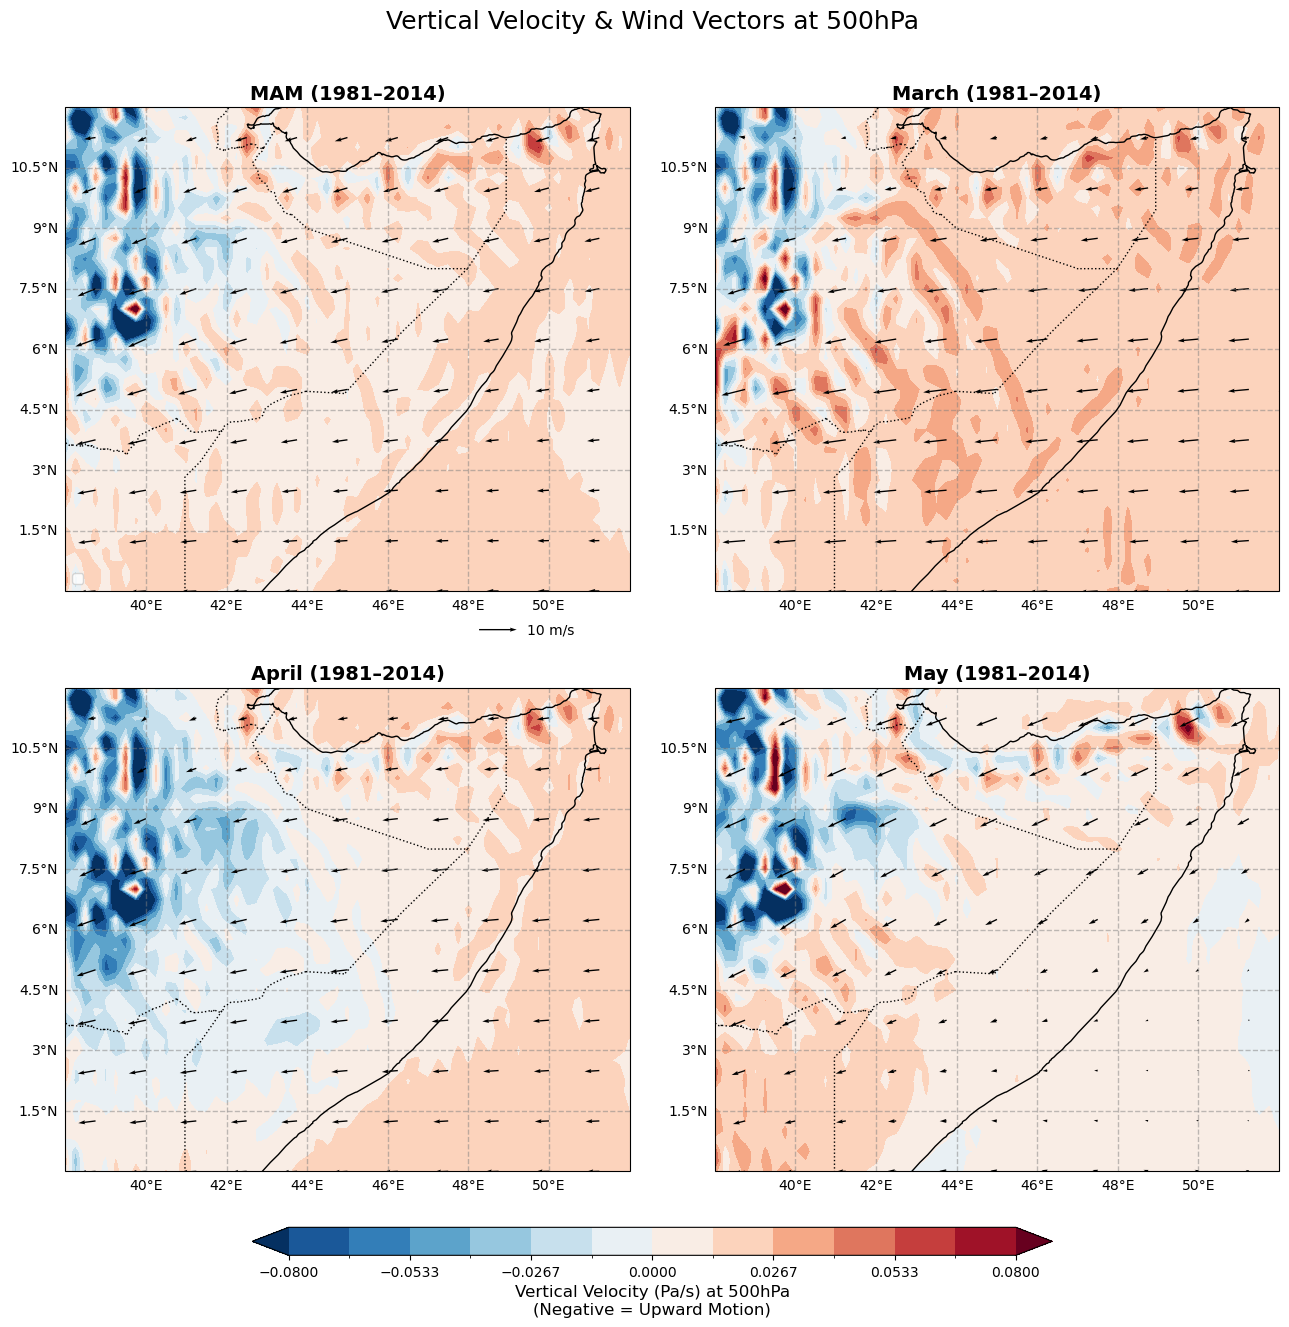

✅ All maps successfully grouped and saved to map_climatology_grouped_wind_vectors.png.


In [ ]:
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# =============================================================================
# PLOTTING (Refactored for Multi-Panel Grouping)
# =============================================================================

cbar_label_text = (
    f'Vertical Velocity (Pa/s) at {int(OMEGA_LEVEL)}hPa\n'
    '(Negative = Upward Motion)'
)

vmax_unified = 0.08
unified_levels = np.linspace(-vmax_unified, vmax_unified, 13)

def plot_climatology_panel(ax, data_to_plot, u_wind, v_wind, cmap, main_title, extent, levels):
    """Plots a single climatology map onto a provided standard axes (ax)."""
    
    # Plot the filled contours (add_colorbar=False so we can make a shared one later)
    cf = data_to_plot.plot.contourf(
        ax=ax, transform=ccrs.PlateCarree(), cmap=cmap, levels=levels,
        extend='both', add_colorbar=False
    )

    skip = 5
    q = ax.quiver(
        u_wind.lon[::skip], u_wind.lat[::skip],
        u_wind.values[::skip, ::skip], v_wind.values[::skip, ::skip],
        transform=ccrs.PlateCarree(), scale=150, color='black', zorder=2
    )
    
    # Only add the quiver key to the first plot to avoid clutter
    if ax.get_subplotspec().colspan.start == 0 and ax.get_subplotspec().rowspan.start == 0:
        ax.quiverkey(q, X=0.8, Y=-0.08, U=10, label='10 m/s', labelpos='E')

    ax.add_feature(cfeature.COASTLINE, edgecolor='black', zorder=3)
    ax.add_feature(cfeature.BORDERS, linestyle=':', zorder=3)
    gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    legend_handles = []
    box_styles = {
        'study': {'name': 'study', 'label': 'Study Region', 'style': {'edgecolor': 'purple', 'linewidth': 3, 'linestyle': '-'}},
        'ea': {'name': 'ea', 'label': 'East Africa', 'style': {'edgecolor': 'green', 'linewidth': 2, 'linestyle': '--'}}
    }

    for box_info in [box_styles['study'], box_styles['ea']]:
        b = config.BOUNDS[box_info['name']]
        rect_style = {**box_info['style'], 'facecolor': 'none'}
        rect = Rectangle(
            xy=(b['lon_min'], b['lat_min']),
            width=(b['lon_max'] - b['lon_min']),
            height=(b['lat_max'] - b['lat_min']),
            transform=ccrs.PlateCarree(),
            zorder=4,
            **rect_style
        )
        
        #ax.add_patch(rect)
        #legend_handles.append(
         #   Line2D([0], [0], label=box_info['label'], color=rect_style['edgecolor'],
          #         linewidth=rect_style.get('linewidth', 1), linestyle=rect_style.get('linestyle', '-'))
        #)
        
    # Only add the legend to the first plot
    #if ax.get_subplotspec().colspan.start == 0 and ax.get_subplotspec().rowspan.start == 0:
    #    ax.legend(handles=legend_handles, loc='lower left', frameon=True)
        
    ax.set_title(main_title, fontsize=14, fontweight='bold')
    
    return cf # Return the contour set for the shared colorbar


# ----------------------------
# Setup the 2x2 Figure Grid
# ----------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 14), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten() # Flatten to a 1D list for easy indexing

# 1. Plot Seasonal MAM (First Panel)
print("Plotting MAM...")
cf_plot = plot_climatology_panel(
    ax=axes[0],
    data_to_plot=omega_mam_clim,
    u_wind=u_mam_clim,
    v_wind=v_mam_clim,
    cmap='RdBu_r',
    main_title=f'MAM ({START_YEAR}–{END_YEAR})',
    extent=extent,
    levels=unified_levels
)

# 2. Plot Individual Months (Remaining Panels)
for i, (month_name, data) in enumerate(monthly_clims.items()):
    ax_idx = i + 1 # Start at index 1 since MAM is at index 0
    print(f"Plotting {month_name}...")
    
    plot_climatology_panel(
        ax=axes[ax_idx],
        data_to_plot=data['omega'], 
        u_wind=data['u'], 
        v_wind=data['v'],
        cmap='RdBu_r',
        main_title=f'{month_name} ({START_YEAR}–{END_YEAR})',
        extent=extent,
        levels=unified_levels
    )

# ----------------------------
# Shared Colorbar & Formatting
# ----------------------------
# Adjust spacing to fit the colorbar without overlapping the maps
fig.subplots_adjust(bottom=0.12, hspace=0.2, wspace=0.1)

# [left, bottom, width, height]
cbar_ax = fig.add_axes([0.25, 0.06, 0.5, 0.02]) 
cbar = fig.colorbar(cf_plot, cax=cbar_ax, orientation='horizontal')
cbar.set_label(cbar_label_text, fontsize=12)

# Set the overarching figure title
fig.suptitle(f'Vertical Velocity & Wind Vectors at {int(OMEGA_LEVEL)}hPa', fontsize=18, y=0.95)

# Save and Show
output_filename = 'map_climatology_grouped_wind_vectors.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

print(f"✅ All maps successfully grouped and saved to {output_filename}.")